In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

tmp_order <- c('Start', 'Sendai', 'Skin', 'Inflamed', 'Delayed',
               'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#3CADBA', '#83E880', '#9C4F43',
                 '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

subclust_order <- c('Start_1', 'Start_2', 'Sendai_1', 'Sendai_2', 'Skin', 'Inflamed',
                    'Delayed_1', 'Delayed_2', 'Delayed_3', 'Fail1_1', 'Fail1_2', 'Fail1_3', 'Fail1_4',
                    'Inter1_1', 'Inter1_2', 'Inter1_3', 'Inter1_4', 'Inter1_5',
                    'Inter2_1', 'Inter2_2', 'Inter2_3', 'Inter2_4',
                    'Fail2_1', 'Fail2_2', 'Fail2_3', 'Fail2_4', 'Fail2_5', 'IPS_1', 'IPS_2', 'IPS_3')
subclust_hexes <- c('#BC687A', '#B96B6B', '#B56F5C', '#AF734B', '#AF7605', '#A57B00', '#988104', '#898600',
                    '#788A07', '#638E03', '#459202', '#21953D', '#049850', '#0A9965', '#009B77', '#049A89',
                    '#079999', '#0B98A8', '#0094B5', '#068FBF', '#2189C3', '#5F81BD', '#777BBF', '#8B75BF',
                    '#9D6EBD', '#AC67B8', '#B762B0', '#BF5FA5', '#C16097', '#C06489')
names(subclust_hexes) <- subclust_order

coolwarm_palette <- c("#1A237E", "#FFFFFF", "#8B0000")

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

umap_theme <- theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: marker gene expression

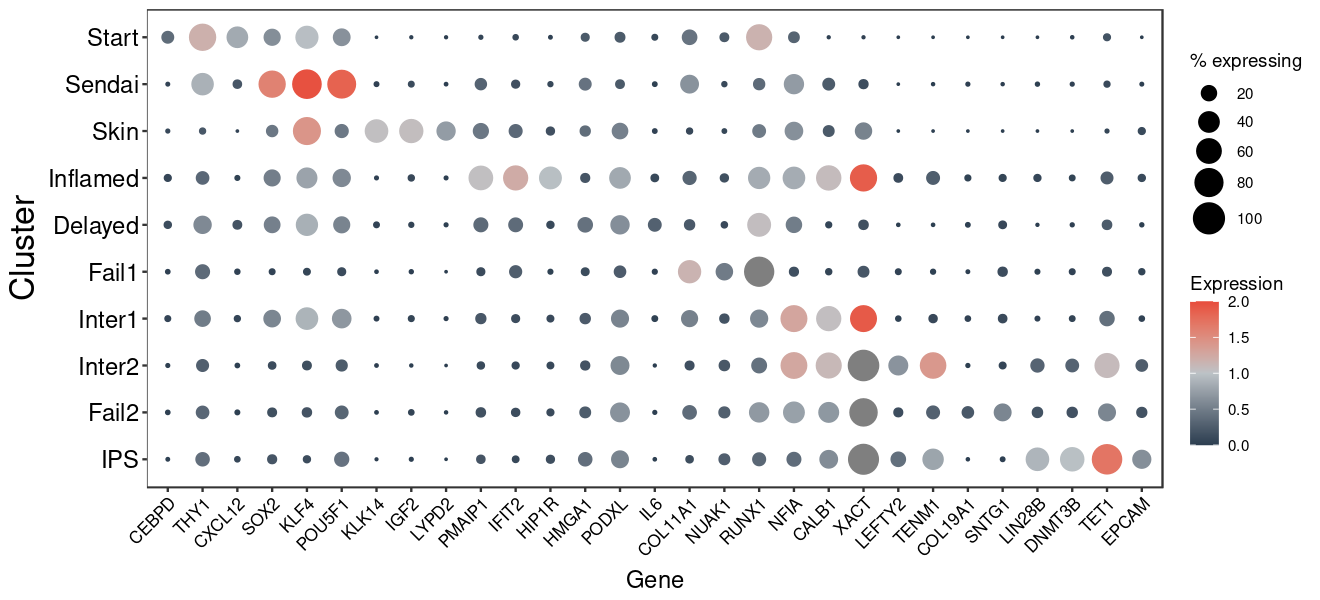

In [ ]:
cell_df_path = paste0(projdir, '/csv/figure1/multiome_dot_plot.csv')
cell_df = as.data.frame(fread(cell_df_path, sep='\t'))
rownames(cell_df) <- cell_df[,1]
cell_df <- cell_df[,-1]

cell_df_meta_path = paste0(projdir, '/csv/figure1/multiome_dot_plot_meta.csv')
cell_df_meta = as.data.frame(fread(cell_df_meta_path, sep='\t'))
colnames(cell_df_meta) <- c('barcode', 'coarse')
cell_df_meta <- cell_df_meta[-1, ]
rownames(cell_df_meta) <- cell_df_meta$barcode

cell_df_meta$coarse <- factor(cell_df_meta$coarse, levels=tmp_order)

tmp_genes <- colnames(cell_df)

cutoff = 1

cell_df$barcode <- rownames(cell_df)

df <- cell_df %>%
  inner_join(cell_df_meta, by = "barcode")

df_long <- df %>%
  select(barcode, coarse, tmp_genes) %>%
  pivot_longer(cols = tmp_genes,
               names_to = "gene",
               values_to = "expr")

dot_df <- df_long %>%
  group_by(coarse, gene) %>%
  summarise(
    avg_expr = mean(expr),
    pct_expr = mean(expr > cutoff) * 100,
    .groups = "drop"
  )

dot_df$gene <- factor(dot_df$gene, levels=tmp_genes)
dot_df$coarse <- factor(dot_df$coarse, levels=rev(tmp_order))

w = 11
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(dot_df, aes(x = gene, y = coarse)) +
  geom_point(aes(size = pct_expr, color = avg_expr)) +
  labs(x='Gene', y='Cluster', size = "% expressing", color = "Expression") +
  scale_color_gradientn(colors = c("#2c3e50", "#bdc3c7", "#e74c3c"), limits = c(0, 2)) +
  scale_size_area(max_size = 8, breaks = c(20, 40, 60, 80, 100), limits = c(0, 100)) +
  theme_bw() +
  theme(
    axis.text.x = element_text(size=10, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size=14, angle = 0, hjust = 1, color='black'),
    axis.title.x = element_text(size=14, angle = 0, vjust=0.5, color='black'),
    axis.title.y = element_text(size=20, angle = 90, vjust=1, color='black'),
    panel.grid = element_blank(),
     panel.background = element_blank(),
     plot.background  = element_blank(),
  )

### B: correlation with Liu et al. 2020

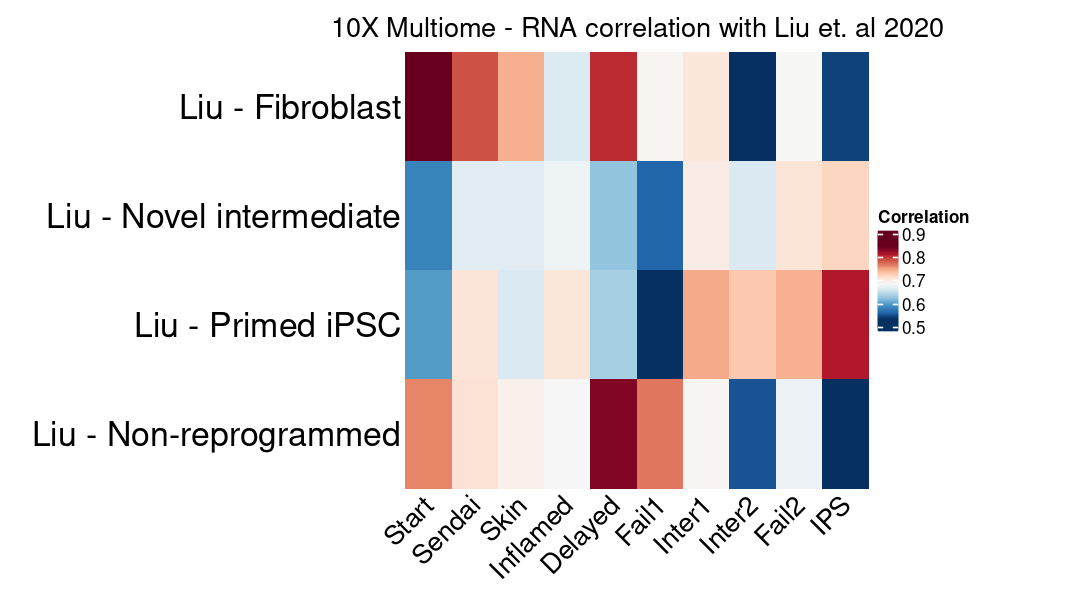

In [ ]:
corr_path = paste0(projdir, '/csv/figure1/liu_igvf_corr.csv')
igvf_liu = as.data.frame(fread(corr_path, sep='\t'))
rownames(igvf_liu) <- igvf_liu$V1
igvf_liu <- igvf_liu[,2:15]

tmp_dict1 <- c('fm' = 'Liu - Fibroblast', 'ni' = 'Liu - Novel intermediate',
              'pr' = 'Liu - Primed iPSC', 're' = 'Liu - Non-reprogrammed')
tmp_dict2 <- c('Fibroblast' = 'Liu - Fibroblast', 'Novel intermediate' = 'Liu - Novel intermediate',
              'Primed iPSC' = 'Liu - Primed iPSC', 'Non-reprogrammed' = 'Liu - Non-reprogrammed')
cols <- colnames(igvf_liu)
tmp_names <- tmp_dict1[cols][1:4]
colnames(igvf_liu) <- c(tmp_names, cols[5:14])
rownames(igvf_liu) <- tmp_dict2[rownames(igvf_liu)]

igvf_liu <- igvf_liu[,5:14]

col_fun <- colorRamp2(
  seq(min(igvf_liu), max(igvf_liu), length.out = 11),
  rev(brewer.pal(11, "RdBu"))
)

w = 9
h = 5
options(repr.plot.width=w, repr.plot.height=h)

igvf_heatmap <- Heatmap(igvf_liu,
                        name='Correlation',
                    row_names_side = "left",
                    column_names_side = "bottom",
                    col = col_fun,
                    column_title = '10X Multiome - RNA correlation with Liu et. al 2020',
                    row_title = '',
                    show_heatmap_legend = TRUE,
                    show_column_names=TRUE,
                    show_row_names=TRUE,
                    row_title_gp = gpar(fontsize = 16),
                    column_title_gp = gpar(fontsize = 16),
                    row_names_gp = gpar(fontsize=20),
                    column_names_gp = gpar(fontsize=16),
                    column_names_rot = 45,
                    heatmap_width = unit(16, "cm"),
                    heatmap_height = unit(12, "cm"),
                    cluster_rows = FALSE,
                    cluster_columns = FALSE)
igvf_heatmap

### C: 10x RNA UMAP, subclusters

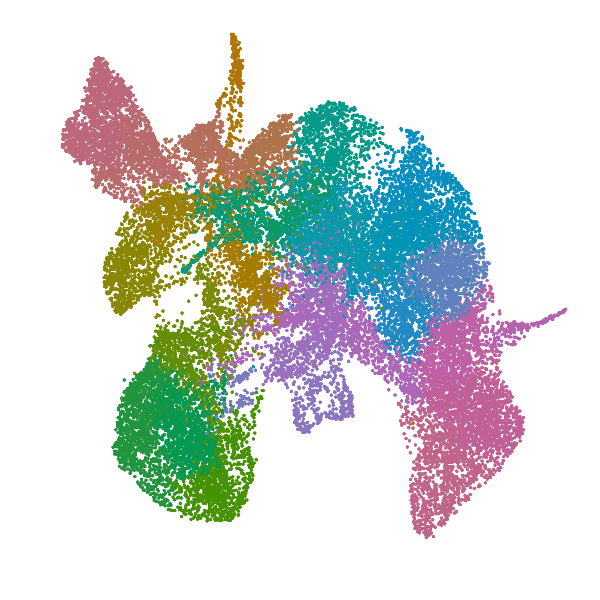

In [ ]:
multiome_rna_umap_path = paste0(projdir, '/csv/figure1/multiome_rna_umap.csv')
multiome_rna_umap = as.data.frame(fread(multiome_rna_umap_path, sep='\t'))
multiome_rna_umap$coarse_v7 <- factor(multiome_rna_umap$coarse_v7, levels=tmp_order)
multiome_rna_umap$clusters_v7 <- factor(multiome_rna_umap$clusters_v7, levels=subclust_order)

set.seed(1)
shuffled_multiome_rna_umap <- multiome_rna_umap[sample(nrow(multiome_rna_umap)), ]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_rna_umap, aes(x = umap0, y = umap1, color = clusters_v7)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", color = 'Clusters') +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_manual(values = subclust_hexes)

### D: 10x RNA UMAP, trajectory score

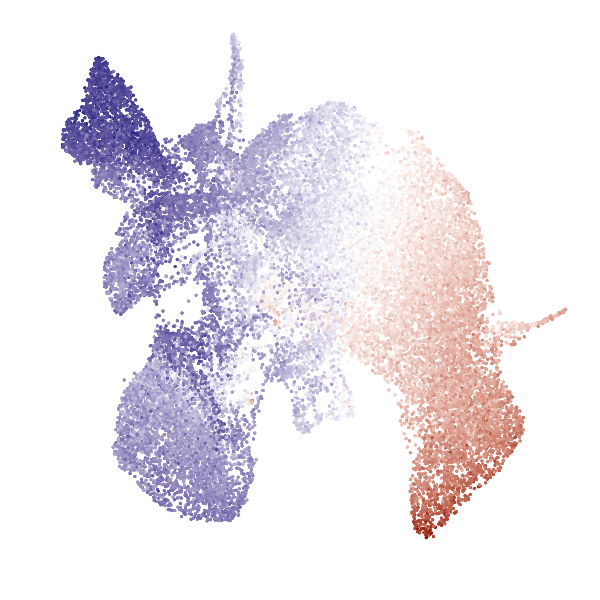

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_rna_umap, aes(x = umap0, y = umap1, color = norm_traj)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_gradientn(colors = coolwarm_palette) +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### E: 10x RNA UMAP, day

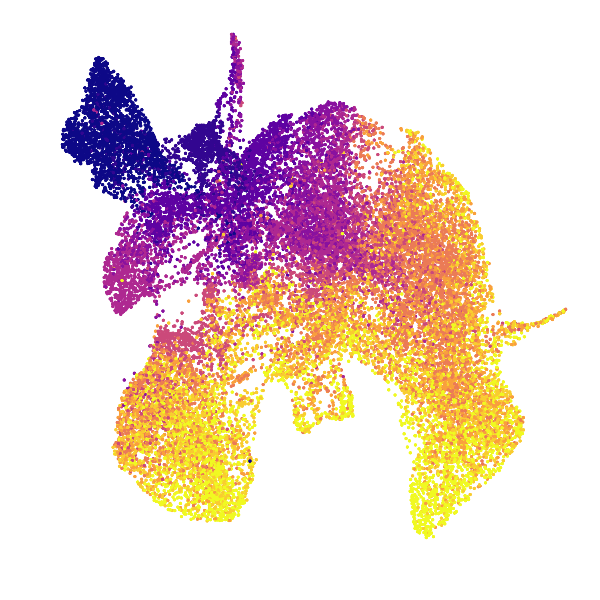

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_rna_umap, aes(x = umap0, y = umap1, color = time_num)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_viridis_c(option = "plasma") +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### F: 10x ATAC UMAP, cluster

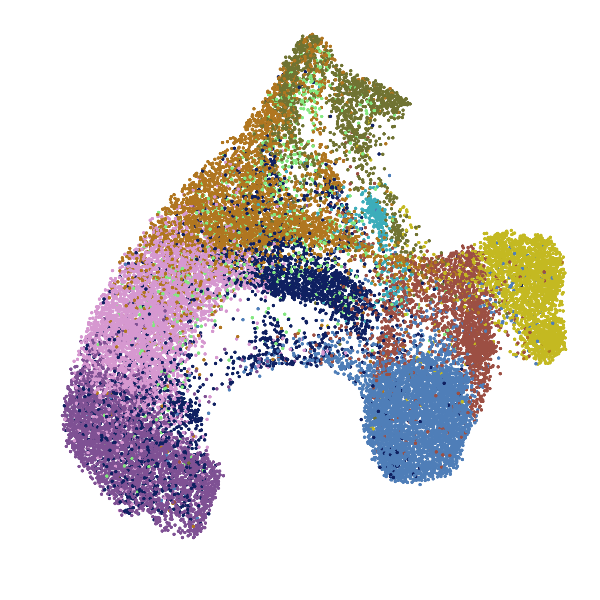

In [ ]:
multiome_atac_umap_path = paste0(projdir, '/csv/figure1/multiome_atac_umap.csv')
multiome_atac_umap = as.data.frame(fread(multiome_atac_umap_path, sep='\t'))
multiome_atac_umap$coarse <- factor(multiome_atac_umap$coarse, levels=tmp_order)

set.seed(1)
shuffled_multiome_atac_umap <- multiome_atac_umap[sample(nrow(multiome_atac_umap)), ]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_atac_umap, aes(x = umap0, y = umap1, color = coarse)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_manual(values=clust_hexes)

### G: 10x ATAC UMAP, trajectory score

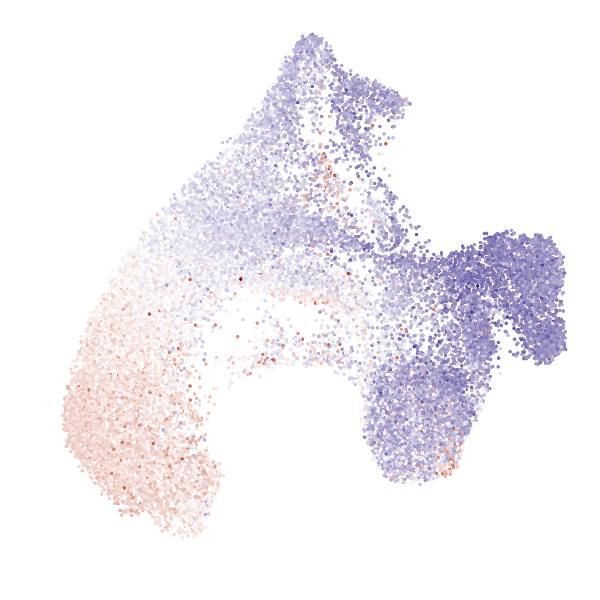

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_atac_umap, aes(x = umap0, y = umap1, color = norm_traj)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_gradientn(colors = coolwarm_palette) +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### H: 10x ATAC UMAP, day

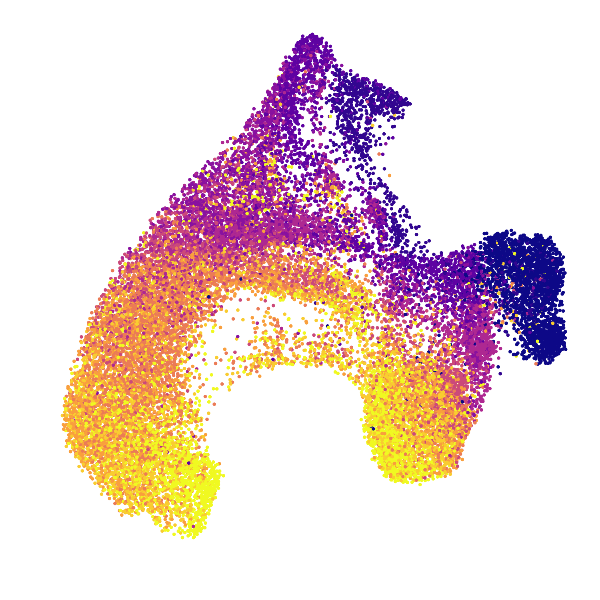

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_atac_umap, aes(x = umap0, y = umap1, color = time_num)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_viridis_c(option = "plasma") +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### I: snmCT-seq RNA UMAP, cluster

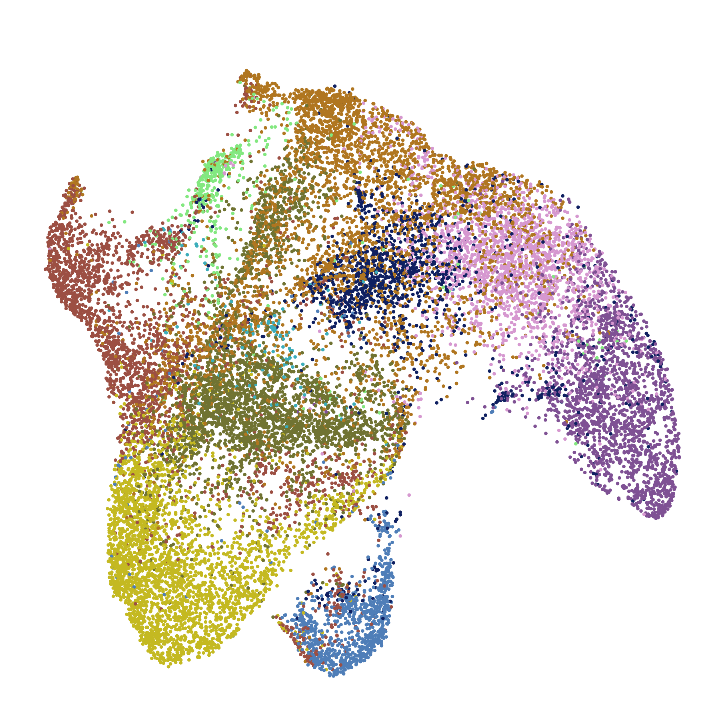

In [ ]:
snmct_path = paste0(projdir, '/csv/figure1/snmct_umap_meta.csv')
snmct_umap = read.csv(snmct_path, sep='\t')
snmct_umap$coarse <- factor(snmct_umap$coarse, levels=tmp_order)

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_snmct_umap <- snmct_umap[sample(nrow(snmct_umap)), ]

ggplot(shuffled_snmct_umap, aes(x = umap0, y = umap1, color = coarse)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", title='') +
  theme_bw() +
  umap_theme +
        scale_color_manual(values = clust_hexes)

### J: snmCT-seq RNA UMAP, trajectory score

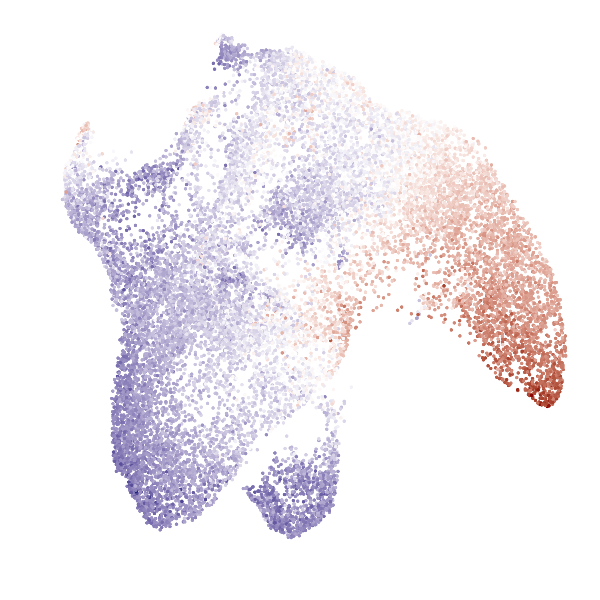

In [ ]:
snmct_rna_umap_path = paste0(projdir, '/csv/figure1/snmct_rna_umap.csv')
snmct_rna_umap = as.data.frame(fread(snmct_rna_umap_path, sep='\t'))

set.seed(1)
shuffled_snmct_rna_umap <- snmct_rna_umap[sample(nrow(snmct_rna_umap)), ]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_snmct_rna_umap, aes(x = umap0, y = umap1, color = norm_traj)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_gradientn(colors = coolwarm_palette) +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### K: snmCT-seq RNA UMAP, day

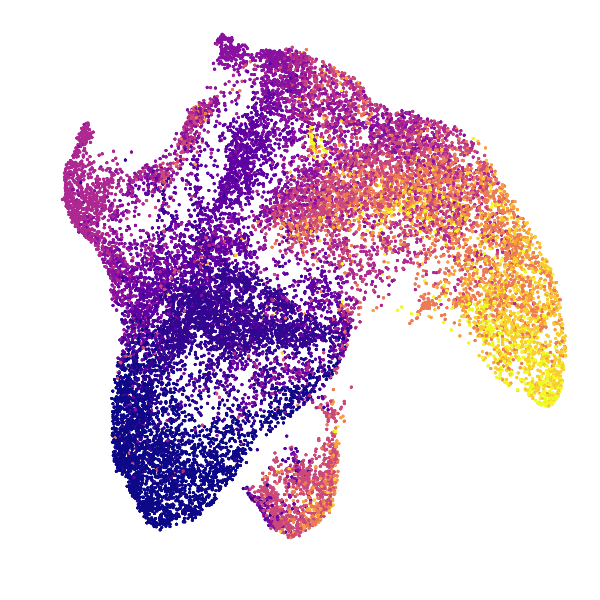

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_snmct_rna_umap, aes(x = umap0, y = umap1, color = time)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_viridis_c(option = "plasma") +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### L: snm3C-seq 3C UMAP, cluster

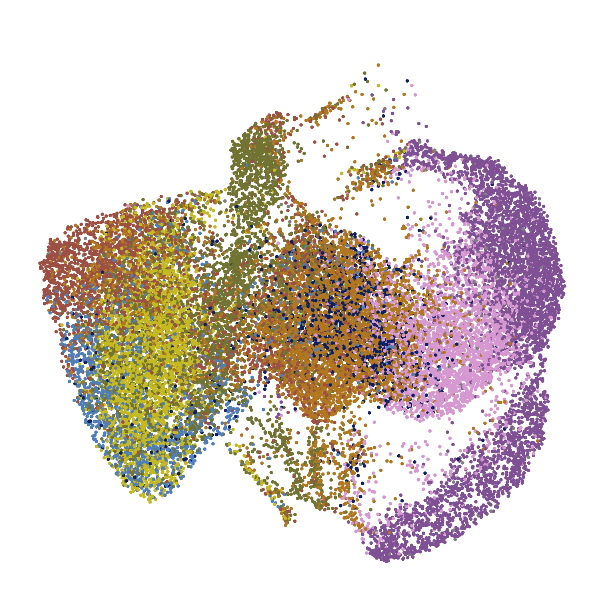

In [ ]:
snm3c_higashi_umap_path = paste0(projdir, '/csv/figure1/snm3c_higashi_umap.csv')
snm3c_higashi_umap = as.data.frame(fread(snm3c_higashi_umap_path, sep='\t'))
snm3c_higashi_umap$cluster <- factor(snm3c_higashi_umap$cluster, levels=tmp_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

set.seed(1)
shuffled_snm3c_higashi_umap <- snm3c_higashi_umap[sample(nrow(snm3c_higashi_umap)), ]

ggplot(shuffled_snm3c_higashi_umap, aes(x = umap0, y = umap1, color = cluster)) +
  geom_point_rast(size = 0.1) +
labs(x = "", y = "", color = 'Cluster', title='') +
  theme_bw() +
   umap_theme +
    scale_color_manual(values=clust_hexes)

### M: snm3C-seq 3C UMAP, trajectory score

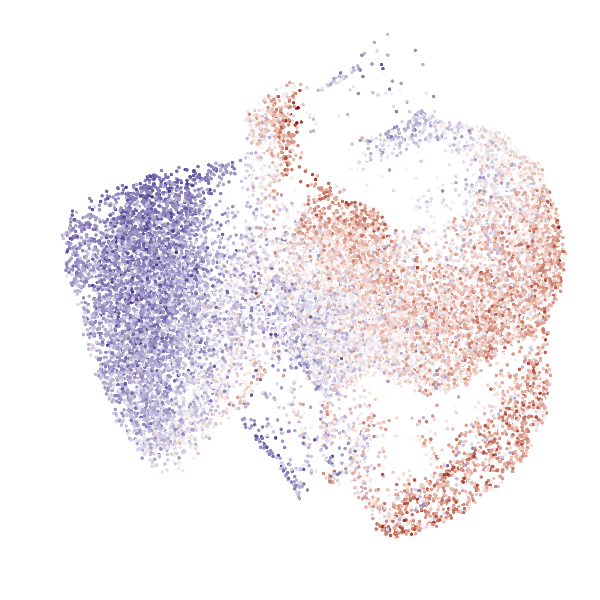

In [ ]:
snm3c_higashi_umap_path = paste0(projdir, '/csv/figure1/snm3c_higashi_umap.csv')
snm3c_higashi_umap = as.data.frame(fread(snm3c_higashi_umap_path, sep='\t'))
snm3c_higashi_umap$cluster <- factor(snm3c_higashi_umap$cluster, levels=tmp_order)
mask <- !is.na(snm3c_higashi_umap$norm_traj)
snm3c_higashi_umap <- snm3c_higashi_umap[mask,]

set.seed(1)
shuffled_snm3c_higashi_umap <- snm3c_higashi_umap[sample(nrow(snm3c_higashi_umap)), ]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_snm3c_higashi_umap, aes(x = umap0, y = umap1, color = norm_traj)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_gradientn(colors = coolwarm_palette) +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

### N: snm3C-seq 3C UMAP, day

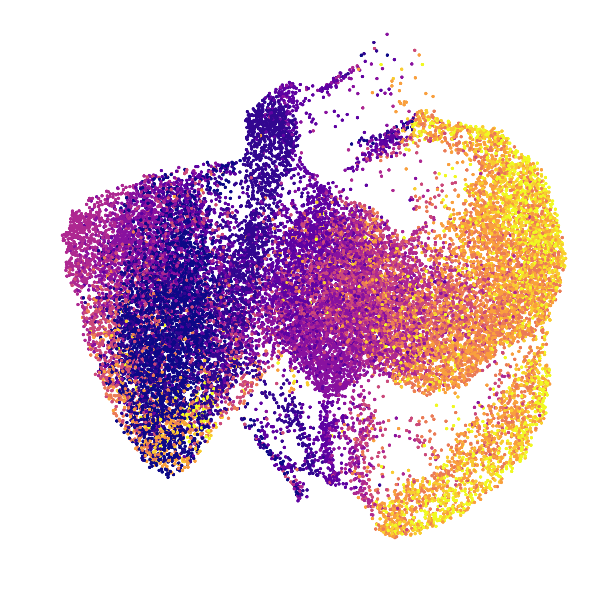

In [ ]:
w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_snm3c_higashi_umap, aes(x = umap0, y = umap1, color = time)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "") +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_viridis_c(option = "plasma") +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

In [ ]:
sessionInfo()

In [ ]:
Sys.time()